# TIV model simulation for within-host influenza dynamics

Influenza infection is a problem of how a small inoculum expands within a single host, how infected cells amplify the viral signal, and how the virus eventually falls back toward undetectable levels. I use the target-infected-virus model from Nowak and Bangham (1996) as a mean-field approximation of target-cell-limited infection, and I follow the parameterization used by Baccam et al. (2006) for influenza A in humans. In this notebook I simulate the baseline dynamics and then examine how two biologically meaningful parameters alter the trajectory.

In [10]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp

np.random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["font.size"] = 12
plt.rcParams["lines.linewidth"] = 1.8

project_dir = Path.cwd()
if not (project_dir / "src").exists():
    project_dir = project_dir.parent

sys.path.append(str(project_dir / "src"))
from tiv_model import solve_tiv

The model consists of three ordinary differential equations for target cells $T$, infected cells $I$, and free virus $V$:

$\frac{dT}{dt} = -\beta T V$
$\frac{dI}{dt} = \beta T V - \delta I$
$\frac{dV}{dt} = p I - c V$

The values below are taken from Baccam et al. (2006) and are useful as a starting point for thinking about the biology rather than as a final fitted estimate.

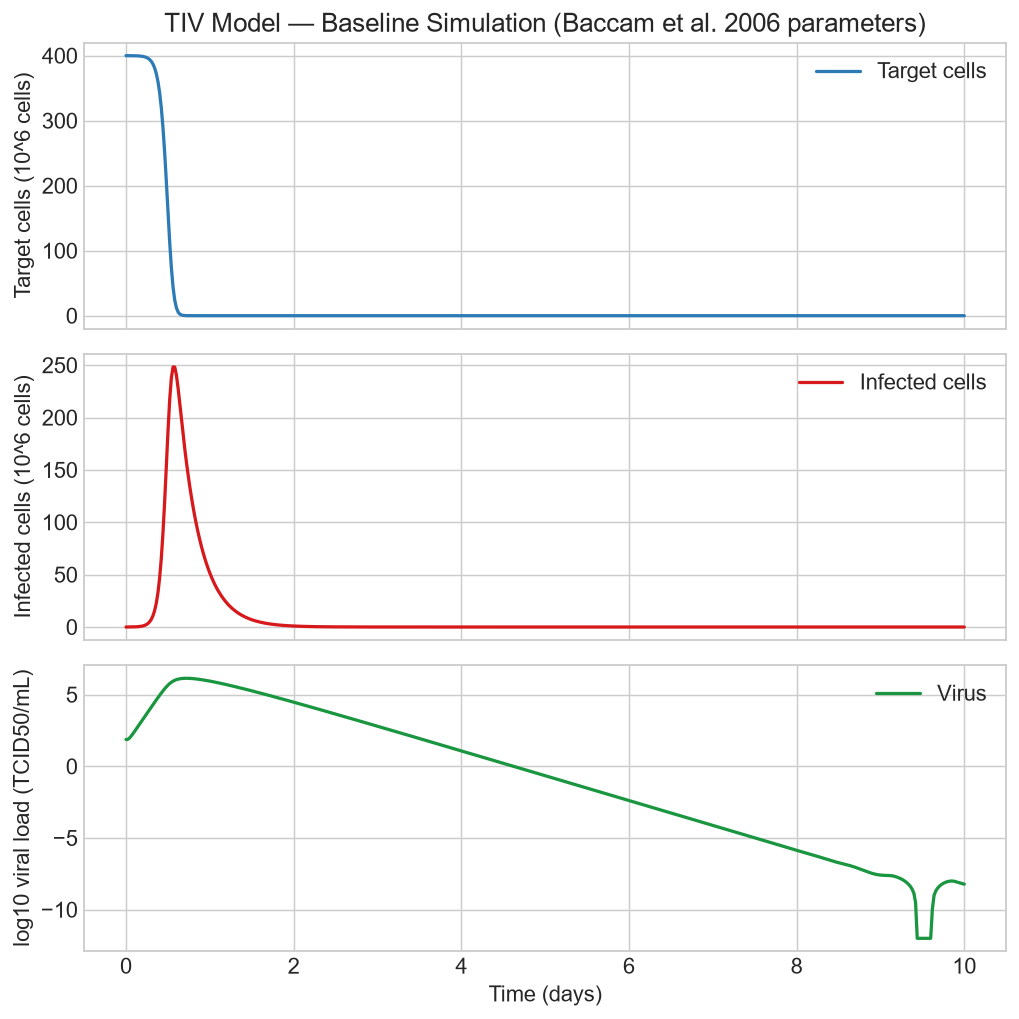

In [ ]:
params = {
    "beta": 3.2e-5,
    "delta": 4.0,
    "p": 4.6e-2,
    "c": 5.2,
}

y0 = [4e8, 0.0, 75.0]
t_eval = np.linspace(0, 10, 500)
solution = solve_tiv(params, (0, 10), t_eval, y0=y0)

T = solution.y[0] / 1e6
I = solution.y[1] / 1e6
V = np.maximum(solution.y[2], 1e-3)

fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

axes[0].plot(t_eval, T, color="#2C7BB6", label="Target cells")
axes[0].set_ylabel("Target cells (10^6 cells)")
axes[0].set_title("TIV Model — Baseline Simulation (Baccam et al. 2006 parameters)")
axes[0].legend()

axes[1].plot(t_eval, I, color="#D7191C", label="Infected cells")
axes[1].set_ylabel("Infected cells (10^6 cells)")
axes[1].legend()

axes[2].plot(t_eval, np.log10(np.maximum(V, 1e-3)), color="#1A9641", label="Virus")
axes[2].set_xlabel("Time (days)")
axes[2].set_ylabel("log10 viral load (TCID50/mL)")
axes[2].legend()

plt.tight_layout()
output_path = project_dir / "figures" / "01_baseline_simulation.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()

The figure shows the essential shape of a within-host influenza infection. The viral load rises quickly after the initial inoculum, reaches a peak near the second day of infection, and then falls as target cells become depleted and free virus is cleared. The infected-cell compartment rises later because it depends on the prior spread of infection rather than on the initial inoculum itself.

In [7]:
R0 = (params["beta"] * params["p"] * y0[0]) / (params["delta"] * params["c"])
print("Basic reproduction number R0 =", R0)

Basic reproduction number R0 = 28.307692307692303


When $R_0 > 1$, one infected cell produces enough new infected cells through its progeny to sustain growth before it dies. In this within-host setting, that means the infection can expand rather than simply fade away after the initial inoculum.

The parameter $\delta$ controls how quickly infected cells are cleared. I varied it across a biologically plausible range to see its effect on peak viral load and infection duration.

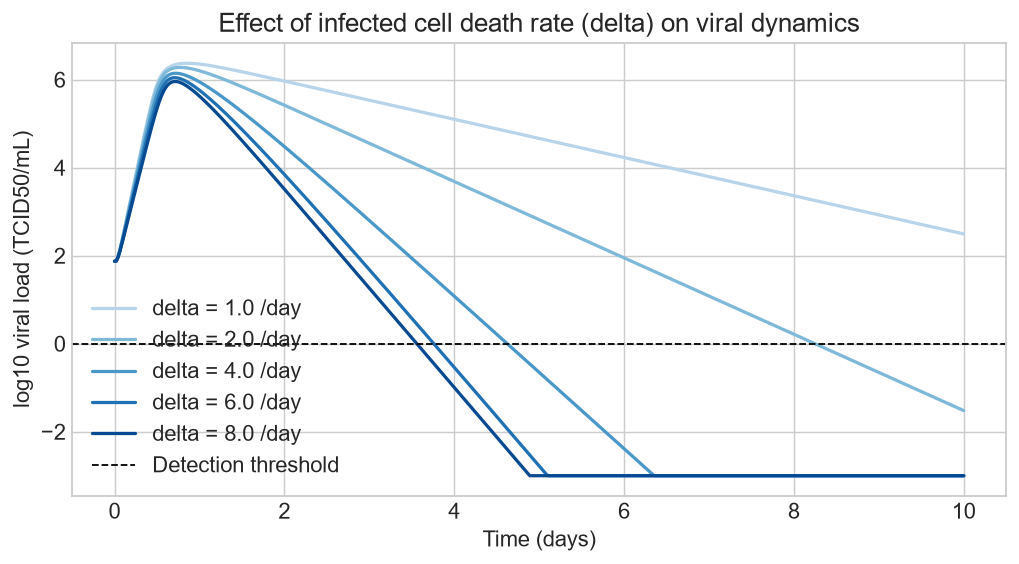

In [13]:
deltas = np.array([1.0, 2.0, 4.0, 6.0, 8.0])
fig, ax = plt.subplots(figsize=(8, 4.5))

cmap = plt.cm.Blues(np.linspace(0.3, 0.9, len(deltas)))
for delta, color in zip(deltas, cmap):
    params_delta = dict(params)
    params_delta["delta"] = delta
    sol = solve_tiv(params_delta, (0, 10), t_eval, y0=y0)
    V_delta = np.maximum(sol.y[2], 1e-3)
    ax.plot(t_eval, np.log10(np.maximum(V_delta, 1e-3)), color=color, label=f"delta = {delta} /day")

ax.axhline(0, color="black", linestyle="--", linewidth=1.0, label="Detection threshold")
ax.set_xlabel("Time (days)")
ax.set_ylabel("log10 viral load (TCID50/mL)")
ax.set_title("Effect of infected cell death rate (delta) on viral dynamics")
ax.legend()

plt.tight_layout()
output_path = project_dir / "figures" / "02_delta_sensitivity.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()

Higher values of $\delta$ shorten the infectious lifetime of infected cells, so the virus peaks earlier and usually at a lower height. The biological mechanism is straightforward: faster infected-cell turnover reduces the time window over which cells can produce virus. This is conceptually related to stronger cytotoxic T-cell responses, which can vary substantially between individuals.

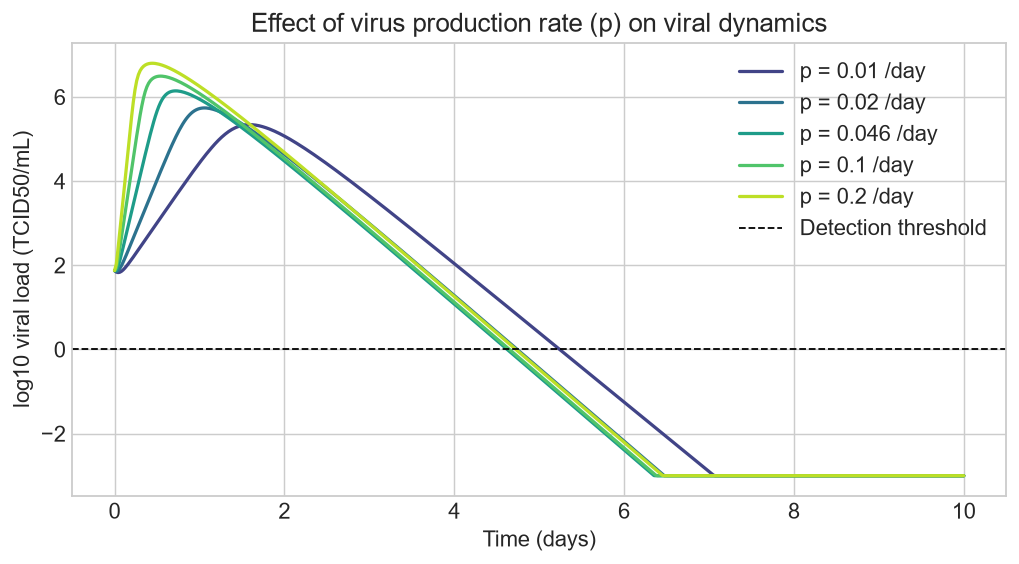

In [14]:
ps = np.array([1e-2, 2e-2, 4.6e-2, 1e-1, 2e-1])
fig, ax = plt.subplots(figsize=(8, 4.5))

cmap = plt.cm.viridis(np.linspace(0.2, 0.9, len(ps)))
for p_value, color in zip(ps, cmap):
    params_p = dict(params)
    params_p["p"] = p_value
    sol = solve_tiv(params_p, (0, 10), t_eval, y0=y0)
    V_p = np.maximum(sol.y[2], 1e-3)
    ax.plot(t_eval, np.log10(V_p), color=color, label=f"p = {p_value} /day")

ax.axhline(0, color="black", linestyle="--", linewidth=1.0, label="Detection threshold")
ax.set_xlabel("Time (days)")
ax.set_ylabel("log10 viral load (TCID50/mL)")
ax.set_title("Effect of virus production rate (p) on viral dynamics")
ax.legend()

plt.tight_layout()
output_path = project_dir / "figures" / "03_p_sensitivity.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()

Changing $p$ changes the amount of virus produced by each infected cell. A larger $p$ pushes the viral trajectory upward and makes the peak appear more pronounced, while a smaller $p$ weakens the infection. This is relevant for antiviral therapy because drugs such as neuraminidase inhibitors reduce the efficiency of viral spread and effectively lower the productive output of infected cells.

This notebook shows that the TIV system can reproduce the basic shape of an acute influenza infection with a small number of parameters. The model is deliberately simple: it assumes a well-mixed infected tissue, lacks a separate immune-response compartment beyond target-cell depletion, and does not include spatial structure. In the next notebook I will fit these parameters to a digitized viral-load time course from a real influenza patient so that the model is anchored more directly to observed data.